In [49]:
import os
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

os.chdir("/Users/j.p.barona/Code/Projects/quantihack/")

FEATURE_COLUMNS = [
    "demand", "frequency", "wind", "solar", "hydro", "biomass",
    "ccgt", "coal", "ocgt", "oil", "french_ict", "dutch_ict", "irish_ict",
    "ew_ict", "nemo", "north_south", "scotland_england",
    "pumped", "nuclear",
]
INPUT_WINDOW = 60
FORECAST_HORIZON = 60
TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
NUM_EPOCHS = 100
HIDDEN_WIDTH = 64
DROPOUT = 0.1
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 100

np.random.seed(42)
torch.manual_seed(42)

In [50]:
cleangriddata = pd.read_parquet(
    "data/CleanGridData/data.parquet",
    columns=FEATURE_COLUMNS,
)

In [51]:
print("Data shape:", cleangriddata.shape)
print("Columns:", cleangriddata.columns.tolist())
display(cleangriddata.head())
print("Null values per column:")
print(cleangriddata.isnull().sum())

Data shape: (32247, 19)
Columns: ['demand', 'frequency', 'wind', 'solar', 'hydro', 'biomass', 'ccgt', 'coal', 'ocgt', 'oil', 'french_ict', 'dutch_ict', 'irish_ict', 'ew_ict', 'nemo', 'north_south', 'scotland_england', 'pumped', 'nuclear']


,demand,frequency,wind,solar,hydro,biomass,ccgt,coal,ocgt,oil,french_ict,dutch_ict,irish_ict,ew_ict,nemo,north_south,scotland_england,pumped,nuclear
0,38859.500000,50.111500,1278.500000,0.0,634.500000,0.0,18198.500000,9305.000000,0.0,0.0,912.000000,0.000000,-414.000000,0.0,0.0,0.0,0.0,320.500000,8223.000000
1,36760.541667,50.024979,1735.708333,0.0,588.500000,0.0,16907.937500,8038.791667,0.0,0.0,897.750000,0.000000,-414.208333,0.0,0.0,0.0,0.0,344.125000,8251.541667
2,31319.062500,50.016375,1968.625000,0.0,495.458333,0.0,13176.208333,6311.875000,0.0,0.0,914.916667,0.000000,-354.958333,0.0,0.0,0.0,0.0,112.937500,8323.520833
3,25355.416667,50.008396,2017.770833,0.0,392.562500,0.0,9021.062500,4629.354167,0.0,0.0,998.291667,0.000000,-211.125000,0.0,0.0,0.0,0.0,0.000000,8297.750000
4,26464.708333,50.025208,2129.833333,0.0,439.270833,0.0,9895.583333,4486.416667,0.0,0.0,996.166667,-10.833333,-109.916667,0.0,0.0,0.0,0.0,53.541667,8464.312500


Null values per column:
demand              0
frequency           0
wind                0
solar               0
hydro               0
biomass             0
ccgt                0
coal                0
ocgt                0
oil                 0
french_ict          0
dutch_ict           0
irish_ict           0
ew_ict              0
nemo                0
north_south         0
scotland_england    0
pumped              0
nuclear             0
dtype: int64


## Preprocessing

In [52]:
num_rows = len(cleangriddata)
train_end = int(num_rows * TRAIN_RATIO)
valid_end = train_end + int(num_rows * VALID_RATIO)

train_df = cleangriddata.iloc[:train_end].copy()
valid_df = cleangriddata.iloc[train_end:valid_end].copy()
test_df = cleangriddata.iloc[valid_end:].copy()

print(f"Train rows: {len(train_df)}")
print(f"Valid rows: {len(valid_df)}")
print(f"Test rows: {len(test_df)}")

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df.values)
valid_scaled = scaler.transform(valid_df.values)
test_scaled = scaler.transform(test_df.values)

minimum_required = INPUT_WINDOW + FORECAST_HORIZON
assert len(train_scaled) >= minimum_required, "Train split is too short for windowing"
assert len(valid_scaled) >= minimum_required, "Validation split is too short for windowing"
assert len(test_scaled) >= minimum_required, "Test split is too short for windowing"

print("Scaled split shapes:", train_scaled.shape, valid_scaled.shape, test_scaled.shape)

Train rows: 22572
Valid rows: 4837
Test rows: 4838
Scaled split shapes: (22572, 19) (4837, 19) (4838, 19)


## Windowing

In [53]:
class SequenceWindowDataset(Dataset):
    def __init__(self, data_array, input_window, forecast_horizon):
        self.data_array = data_array.astype(np.float32)
        self.input_window = input_window
        self.forecast_horizon = forecast_horizon
        self.window_count = len(self.data_array) - input_window - forecast_horizon + 1
        if self.window_count <= 0:
            raise ValueError("Data array is too short for requested windows")

    def __len__(self):
        return self.window_count

    def __getitem__(self, index):
        input_start = index
        input_end = input_start + self.input_window
        target_end = input_end + self.forecast_horizon

        x = self.data_array[input_start:input_end]
        y = self.data_array[input_end:target_end]

        return torch.from_numpy(x), torch.from_numpy(y)


train_dataset = SequenceWindowDataset(train_scaled, INPUT_WINDOW, FORECAST_HORIZON)
valid_dataset = SequenceWindowDataset(valid_scaled, INPUT_WINDOW, FORECAST_HORIZON)
test_dataset = SequenceWindowDataset(test_scaled, INPUT_WINDOW, FORECAST_HORIZON)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Window counts:", len(train_dataset), len(valid_dataset), len(test_dataset))

sample_x, sample_y = train_dataset[0]
print("Single sample shapes:", sample_x.shape, sample_y.shape)

batch_x, batch_y = next(iter(train_loader))
print("Batch shapes:", batch_x.shape, batch_y.shape)

Window counts: 22453 4718 4719
Single sample shapes: torch.Size([60, 19]) torch.Size([60, 19])
Batch shapes: torch.Size([128, 60, 19]) torch.Size([128, 60, 19])


## Model

In [54]:
class TemporalResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation, dropout):
        super().__init__()
        padding = dilation * (kernel_size - 1) // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = self.conv1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.conv2(x)
        x = self.activation(x)
        x = self.dropout(x)
        return x + residual


class TemporalConvForecaster(nn.Module):
    def __init__(self, num_features, input_window, forecast_horizon, hidden_width, dropout):
        super().__init__()
        self.forecast_horizon = forecast_horizon
        self.num_features = num_features

        self.input_projection = nn.Conv1d(num_features, hidden_width, kernel_size=1)
        self.temporal_blocks = nn.ModuleList(
            [
                TemporalResidualBlock(hidden_width, kernel_size=3, dilation=1, dropout=dropout),
                TemporalResidualBlock(hidden_width, kernel_size=3, dilation=2, dropout=dropout),
                TemporalResidualBlock(hidden_width, kernel_size=3, dilation=4, dropout=dropout),
                TemporalResidualBlock(hidden_width, kernel_size=3, dilation=8, dropout=dropout),
            ]
        )

        encoded_size = hidden_width * input_window
        self.decoder = nn.Sequential(
            nn.Linear(encoded_size, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, forecast_horizon * num_features),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.input_projection(x)

        for block in self.temporal_blocks:
            x = block(x)

        x = x.flatten(start_dim=1)
        x = self.decoder(x)
        x = x.view(-1, self.forecast_horizon, self.num_features)
        return x


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

model = TemporalConvForecaster(
    num_features=len(FEATURE_COLUMNS),
    input_window=INPUT_WINDOW,
    forecast_horizon=FORECAST_HORIZON,
    hidden_width=HIDDEN_WIDTH,
    dropout=DROPOUT,
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print(model)

Using device: mps
TemporalConvForecaster(
  (input_projection): Conv1d(19, 64, kernel_size=(1,), stride=(1,))
  (temporal_blocks): ModuleList(
    (0): TemporalResidualBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (activation): GELU(approximate='none')
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TemporalResidualBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (activation): GELU(approximate='none')
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (2): TemporalResidualBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (activation): GELU(approximate='none')
      (dro

## Training

In [55]:
train_losses = []
valid_losses = []
best_valid_loss = float("inf")
best_model_state = None
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_train_loss = 0.0
    train_count = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        batch_size = batch_x.size(0)
        running_train_loss += loss.item() * batch_size
        train_count += batch_size

    epoch_train_loss = running_train_loss / train_count
    train_losses.append(epoch_train_loss)

    model.eval()
    running_valid_loss = 0.0
    valid_count = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)

            batch_size = batch_x.size(0)
            running_valid_loss += loss.item() * batch_size
            valid_count += batch_size

    epoch_valid_loss = running_valid_loss / valid_count
    valid_losses.append(epoch_valid_loss)

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {epoch_train_loss:.6f} | "
        f"Valid Loss: {epoch_valid_loss:.6f}"
    )

    if epoch_valid_loss < best_valid_loss:
        best_valid_loss = epoch_valid_loss
        best_model_state = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("Best validation loss:", best_valid_loss)

Epoch 001 | Train Loss: 0.497874 | Valid Loss: 1.570532
Epoch 002 | Train Loss: 0.414493 | Valid Loss: 1.683700
Epoch 003 | Train Loss: 0.375223 | Valid Loss: 1.831284
Epoch 004 | Train Loss: 0.342089 | Valid Loss: 1.860140
Epoch 005 | Train Loss: 0.315240 | Valid Loss: 1.853410
Epoch 006 | Train Loss: 0.296844 | Valid Loss: 1.804310
Epoch 007 | Train Loss: 0.284011 | Valid Loss: 1.821977
Epoch 008 | Train Loss: 0.273656 | Valid Loss: 1.799907
Epoch 009 | Train Loss: 0.265751 | Valid Loss: 1.785332
Epoch 010 | Train Loss: 0.259872 | Valid Loss: 1.793783
Epoch 011 | Train Loss: 0.254376 | Valid Loss: 1.808574
Epoch 012 | Train Loss: 0.250146 | Valid Loss: 1.804210
Epoch 013 | Train Loss: 0.245769 | Valid Loss: 1.802251
Epoch 014 | Train Loss: 0.241831 | Valid Loss: 1.796323
Epoch 015 | Train Loss: 0.238287 | Valid Loss: 1.796606
Epoch 016 | Train Loss: 0.235489 | Valid Loss: 1.795532
Epoch 017 | Train Loss: 0.231850 | Valid Loss: 1.795984
Epoch 018 | Train Loss: 0.229954 | Valid Loss: 1

## Evaluation

Test MSE: 1.788029
Test MAE: 0.774989


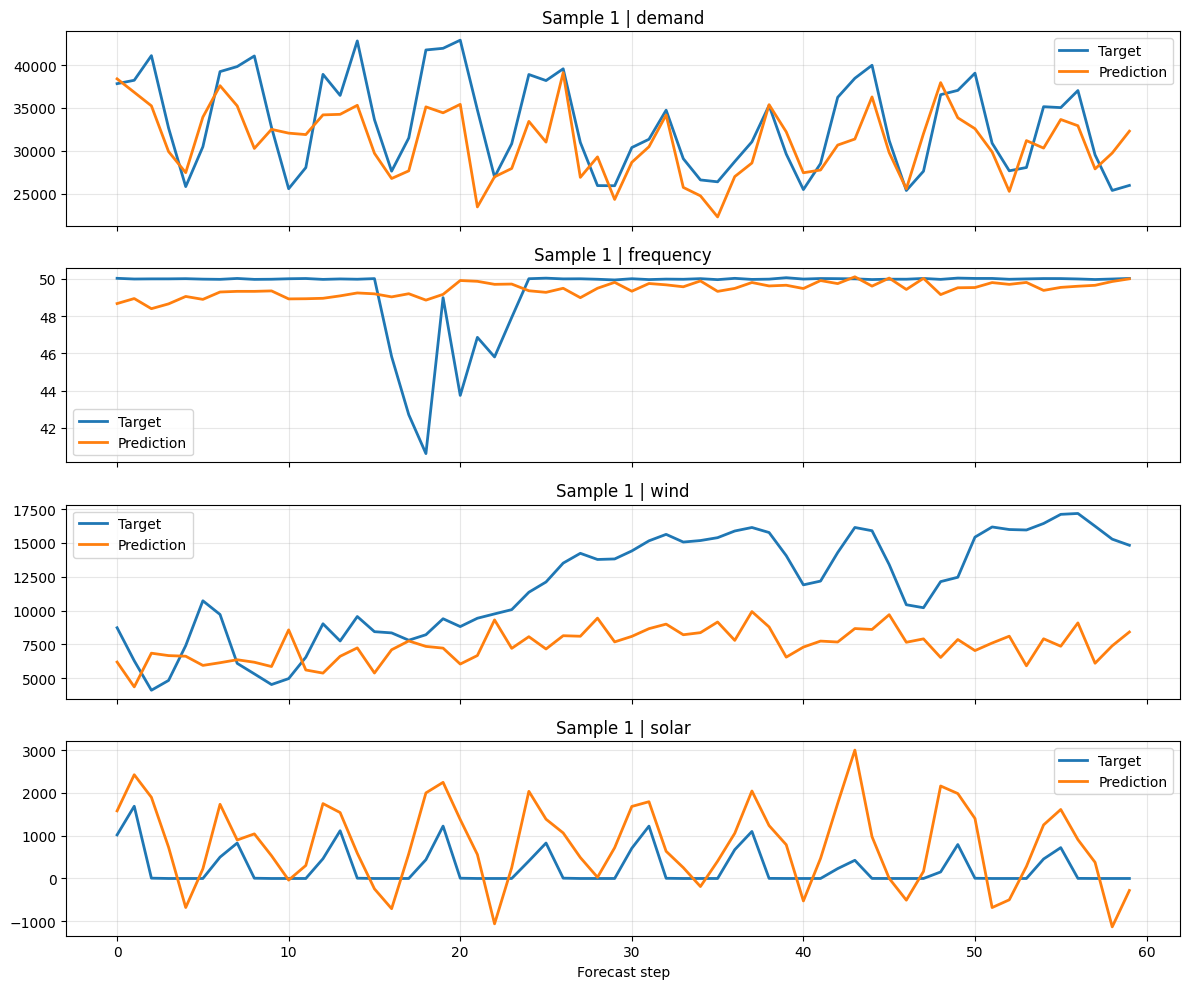

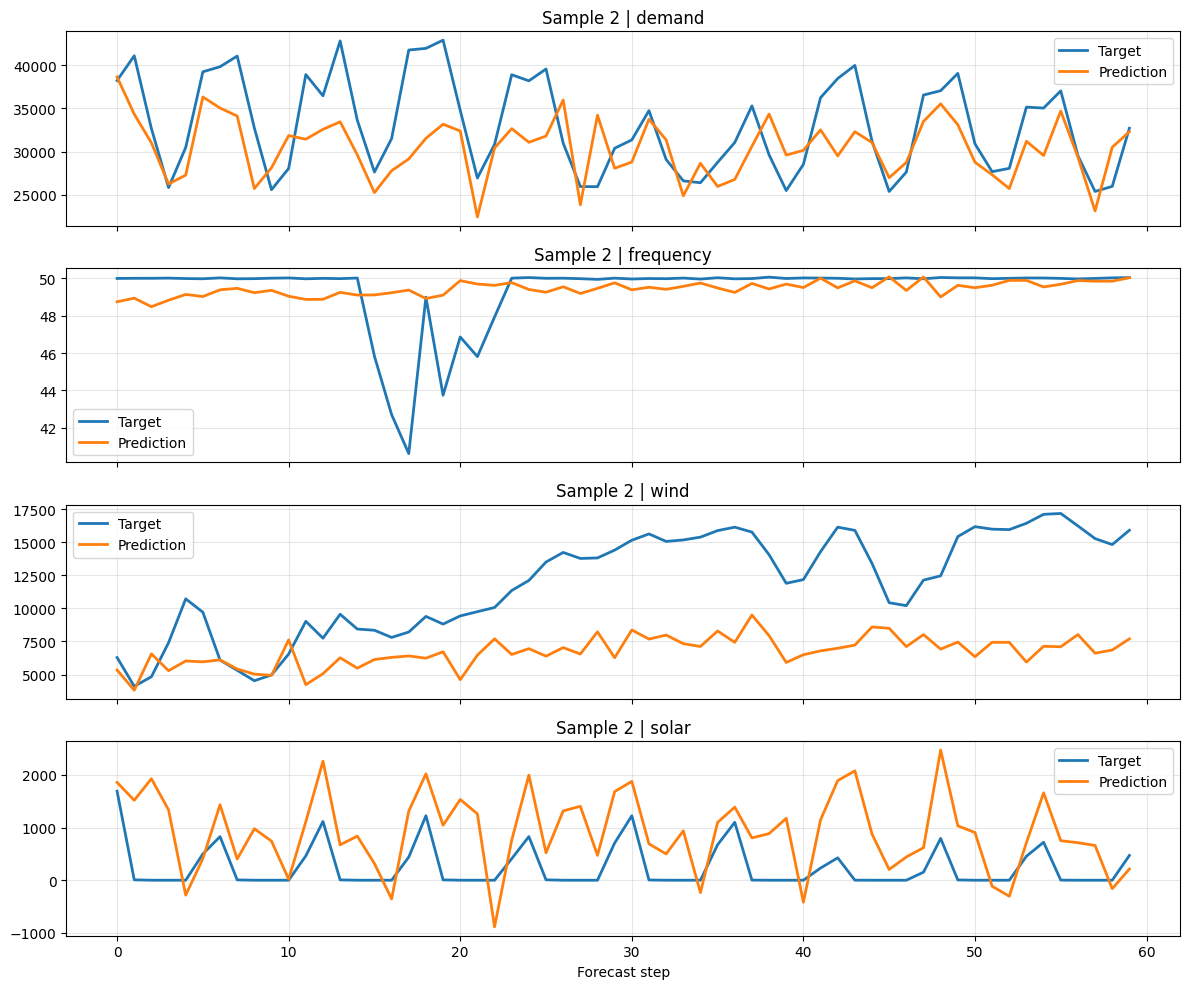

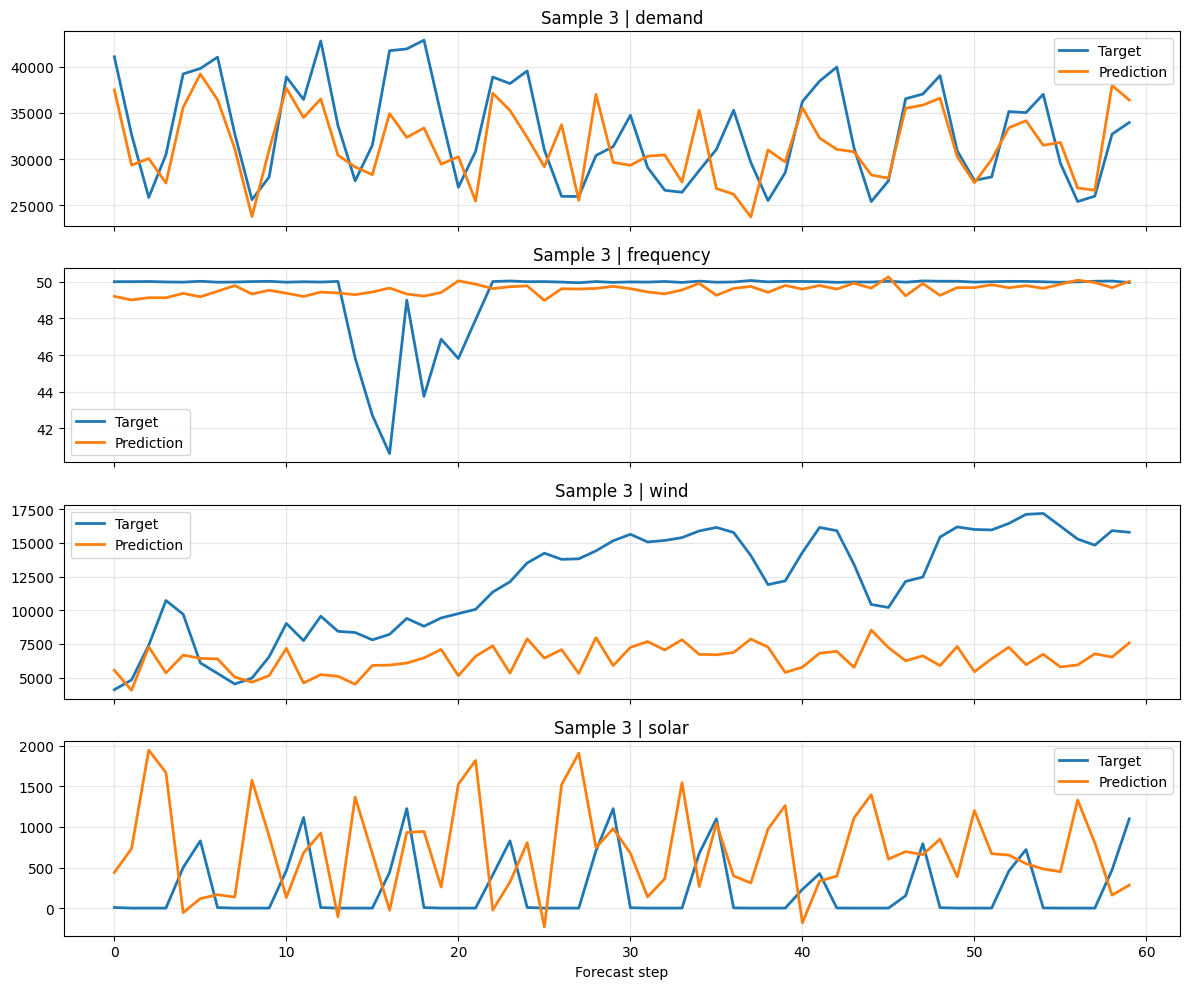

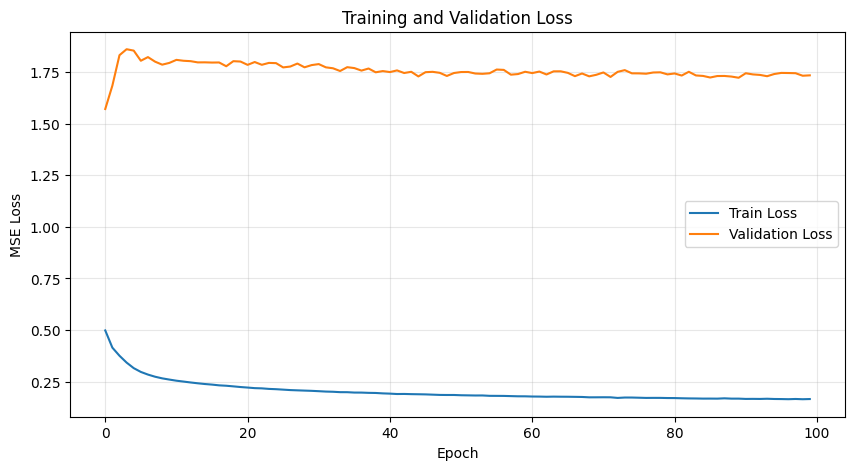

In [59]:
model.eval()
test_mse_total = 0.0
test_mae_total = 0.0
test_count = 0

pred_batches = []
target_batches = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        predictions = model(batch_x)

        mse_loss = nn.functional.mse_loss(predictions, batch_y, reduction="mean")
        mae_loss = nn.functional.l1_loss(predictions, batch_y, reduction="mean")

        batch_size = batch_x.size(0)
        test_mse_total += mse_loss.item() * batch_size
        test_mae_total += mae_loss.item() * batch_size
        test_count += batch_size

        if len(pred_batches) < 3:
            pred_batches.append(predictions.detach().cpu().numpy())
            target_batches.append(batch_y.detach().cpu().numpy())


test_mse = test_mse_total / test_count
test_mae = test_mae_total / test_count

print(f"Test MSE: {test_mse:.6f}")
print(f"Test MAE: {test_mae:.6f}")


def inverse_scale_sequences(sequences_3d, fitted_scaler):
    n_samples, horizon, n_features = sequences_3d.shape
    flattened = sequences_3d.reshape(-1, n_features)
    unscaled = fitted_scaler.inverse_transform(flattened)
    return unscaled.reshape(n_samples, horizon, n_features)


plot_predictions = np.concatenate(pred_batches, axis=0)
plot_targets = np.concatenate(target_batches, axis=0)

plot_predictions = inverse_scale_sequences(plot_predictions, scaler)
plot_targets = inverse_scale_sequences(plot_targets, scaler)

variables_to_plot = ["demand", "frequency", "wind", "solar"]
variable_indices = [FEATURE_COLUMNS.index(name) for name in variables_to_plot]

num_samples_to_plot = min(3, plot_predictions.shape[0])
time_axis = np.arange(FORECAST_HORIZON)

for sample_idx in range(num_samples_to_plot):
    fig, axes = plt.subplots(len(variable_indices), 1, figsize=(12, 10), sharex=True)
    if len(variable_indices) == 1:
        axes = [axes]

    for axis, var_name, var_idx in zip(axes, variables_to_plot, variable_indices):
        axis.plot(time_axis, plot_targets[sample_idx, :, var_idx], label="Target", linewidth=2)
        axis.plot(time_axis, plot_predictions[sample_idx, :, var_idx], label="Prediction", linewidth=2)
        axis.set_title(f"Sample {sample_idx + 1} | {var_name}")
        axis.grid(alpha=0.3)
        axis.legend()

    axes[-1].set_xlabel("Forecast step")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Additional baselines

NLinearBaseline | Epoch 001 | Train 0.651050 | Valid 1.502493
NLinearBaseline | Epoch 002 | Train 0.533640 | Valid 1.427839
NLinearBaseline | Epoch 003 | Train 0.517236 | Valid 1.406765
NLinearBaseline | Epoch 004 | Train 0.511809 | Valid 1.402219
NLinearBaseline | Epoch 005 | Train 0.508699 | Valid 1.397669
NLinearBaseline | Epoch 006 | Train 0.506863 | Valid 1.397459
NLinearBaseline | Epoch 007 | Train 0.505836 | Valid 1.397848
NLinearBaseline | Epoch 008 | Train 0.504909 | Valid 1.395518
NLinearBaseline | Epoch 009 | Train 0.504465 | Valid 1.393480
NLinearBaseline | Epoch 010 | Train 0.505338 | Valid 1.409528
NLinearBaseline | Epoch 011 | Train 0.503786 | Valid 1.394729
NLinearBaseline | Epoch 012 | Train 0.503633 | Valid 1.394611
NLinearBaseline | Epoch 013 | Train 0.504509 | Valid 1.394883
NLinearBaseline | Epoch 014 | Train 0.504108 | Valid 1.392935
NLinearBaseline | Epoch 015 | Train 0.504364 | Valid 1.394085
NLinearBaseline | Epoch 016 | Train 0.503794 | Valid 1.400088
NLinearB

,model,test_mse,test_mae
5,DLinear,1.532146,0.599139
4,NLinear,1.553470,0.575719
3,TemporalConvForecaster,1.788029,0.774989
1,Daily seasonal naive (lag 6),2.482741,0.646576
2,Weekly seasonal naive (lag 42),2.743468,0.677519
0,Last-value persistence,2.954112,0.772091


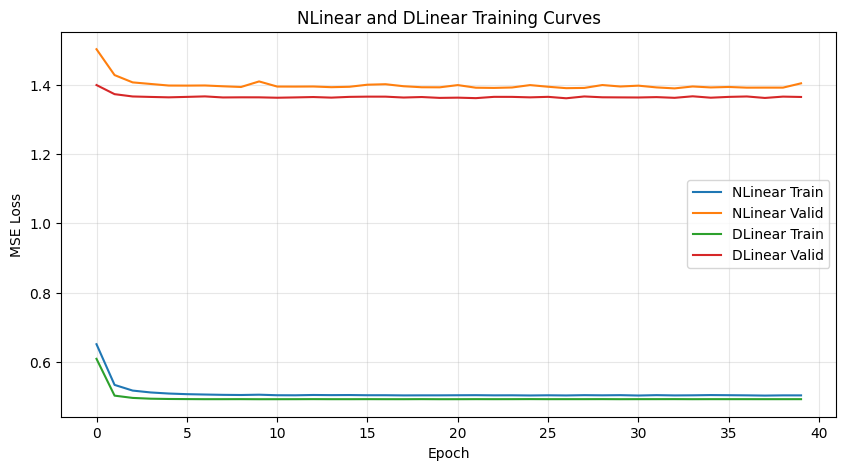

In [57]:
def repeat_last_k(input_batch, horizon, lag):
    pattern = input_batch[:, -lag:, :]
    repeat_factor = (horizon + lag - 1) // lag
    repeated = pattern.repeat(1, repeat_factor, 1)
    return repeated[:, :horizon, :]


def evaluate_rule_baseline(data_loader, horizon, lag):
    mse_total = 0.0
    mae_total = 0.0
    count_total = 0

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            predictions = repeat_last_k(batch_x, horizon=horizon, lag=lag)

            mse = nn.functional.mse_loss(predictions, batch_y, reduction="mean")
            mae = nn.functional.l1_loss(predictions, batch_y, reduction="mean")

            batch_size = batch_x.size(0)
            mse_total += mse.item() * batch_size
            mae_total += mae.item() * batch_size
            count_total += batch_size

    return mse_total / count_total, mae_total / count_total


class NLinearBaseline(nn.Module):
    def __init__(self, input_window, forecast_horizon, num_features):
        super().__init__()
        self.input_window = input_window
        self.forecast_horizon = forecast_horizon
        self.num_features = num_features
        self.linear = nn.Linear(input_window, forecast_horizon)

    def forward(self, x):
        last = x[:, -1:, :]
        normalized = x - last
        normalized = normalized.transpose(1, 2)
        output = self.linear(normalized)
        output = output.transpose(1, 2)
        return output + last


class MovingAverage(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size
        self.padding = (kernel_size - 1) // 2
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1)

    def forward(self, x):
        x = x.transpose(1, 2)
        front = x[:, :, 0:1].repeat(1, 1, self.padding)
        end = x[:, :, -1:].repeat(1, 1, self.padding)
        x = torch.cat([front, x, end], dim=2)
        x = self.avg(x)
        return x.transpose(1, 2)


class DLinearBaseline(nn.Module):
    def __init__(self, input_window, forecast_horizon, num_features, moving_avg_kernel=25):
        super().__init__()
        self.input_window = input_window
        self.forecast_horizon = forecast_horizon
        self.num_features = num_features
        self.decomposition = MovingAverage(kernel_size=moving_avg_kernel)
        self.trend_linear = nn.Linear(input_window, forecast_horizon)
        self.seasonal_linear = nn.Linear(input_window, forecast_horizon)

    def forward(self, x):
        trend = self.decomposition(x)
        seasonal = x - trend

        trend = trend.transpose(1, 2)
        seasonal = seasonal.transpose(1, 2)

        trend_out = self.trend_linear(trend)
        seasonal_out = self.seasonal_linear(seasonal)

        output = trend_out + seasonal_out
        return output.transpose(1, 2)


def train_learned_baseline(model, train_loader, valid_loader, num_epochs, learning_rate, weight_decay, patience):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    best_state = None
    best_valid = float("inf")
    wait = 0

    history_train = []
    history_valid = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_train = 0.0
        count_train = 0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()

            batch_size = batch_x.size(0)
            total_train += loss.item() * batch_size
            count_train += batch_size

        epoch_train = total_train / count_train
        history_train.append(epoch_train)

        model.eval()
        total_valid = 0.0
        count_valid = 0

        with torch.no_grad():
            for batch_x, batch_y in valid_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)

                preds = model(batch_x)
                loss = criterion(preds, batch_y)

                batch_size = batch_x.size(0)
                total_valid += loss.item() * batch_size
                count_valid += batch_size

        epoch_valid = total_valid / count_valid
        history_valid.append(epoch_valid)

        print(
            f"{model.__class__.__name__} | Epoch {epoch:03d} | "
            f"Train {epoch_train:.6f} | Valid {epoch_valid:.6f}"
        )

        if epoch_valid < best_valid:
            best_valid = epoch_valid
            best_state = deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            print(f"{model.__class__.__name__} early stopping")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history_train, history_valid, best_valid


def evaluate_learned_model(model, data_loader):
    model.eval()
    mse_total = 0.0
    mae_total = 0.0
    count_total = 0

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_x)
            mse = nn.functional.mse_loss(predictions, batch_y, reduction="mean")
            mae = nn.functional.l1_loss(predictions, batch_y, reduction="mean")

            batch_size = batch_x.size(0)
            mse_total += mse.item() * batch_size
            mae_total += mae.item() * batch_size
            count_total += batch_size

    return mse_total / count_total, mae_total / count_total


baseline_results = []

last_value_mse, last_value_mae = evaluate_rule_baseline(test_loader, FORECAST_HORIZON, lag=1)
baseline_results.append({"model": "Last-value persistence", "test_mse": last_value_mse, "test_mae": last_value_mae})

daily_naive_mse, daily_naive_mae = evaluate_rule_baseline(test_loader, FORECAST_HORIZON, lag=6)
baseline_results.append({"model": "Daily seasonal naive (lag 6)", "test_mse": daily_naive_mse, "test_mae": daily_naive_mae})

weekly_naive_mse, weekly_naive_mae = evaluate_rule_baseline(test_loader, FORECAST_HORIZON, lag=42)
baseline_results.append({"model": "Weekly seasonal naive (lag 42)", "test_mse": weekly_naive_mse, "test_mae": weekly_naive_mae})

baseline_results.append({"model": "TemporalConvForecaster", "test_mse": test_mse, "test_mae": test_mae})

LEARNED_BASELINE_EPOCHS = 40

nlinear_model = NLinearBaseline(
    input_window=INPUT_WINDOW,
    forecast_horizon=FORECAST_HORIZON,
    num_features=len(FEATURE_COLUMNS),
).to(device)

nlinear_train_losses, nlinear_valid_losses, _ = train_learned_baseline(
    nlinear_model,
    train_loader,
    valid_loader,
    num_epochs=LEARNED_BASELINE_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=EARLY_STOPPING_PATIENCE,
)

nlinear_test_mse, nlinear_test_mae = evaluate_learned_model(nlinear_model, test_loader)
baseline_results.append({"model": "NLinear", "test_mse": nlinear_test_mse, "test_mae": nlinear_test_mae})


dlinear_model = DLinearBaseline(
    input_window=INPUT_WINDOW,
    forecast_horizon=FORECAST_HORIZON,
    num_features=len(FEATURE_COLUMNS),
    moving_avg_kernel=25,
).to(device)

dlinear_train_losses, dlinear_valid_losses, _ = train_learned_baseline(
    dlinear_model,
    train_loader,
    valid_loader,
    num_epochs=LEARNED_BASELINE_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=EARLY_STOPPING_PATIENCE,
)

dlinear_test_mse, dlinear_test_mae = evaluate_learned_model(dlinear_model, test_loader)
baseline_results.append({"model": "DLinear", "test_mse": dlinear_test_mse, "test_mae": dlinear_test_mae})

baseline_results_df = pd.DataFrame(baseline_results).sort_values(by="test_mse")
display(baseline_results_df)

plt.figure(figsize=(10, 5))
plt.plot(nlinear_train_losses, label="NLinear Train")
plt.plot(nlinear_valid_losses, label="NLinear Valid")
plt.plot(dlinear_train_losses, label="DLinear Train")
plt.plot(dlinear_valid_losses, label="DLinear Valid")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("NLinear and DLinear Training Curves")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [58]:
test_scaled_df = pd.DataFrame(test_scaled, columns=FEATURE_COLUMNS)
print(test_scaled_df.abs().mean().sort_values(ascending=False))

nuclear             2.272522
wind                1.854958
dutch_ict           1.655851
nemo                1.510765
irish_ict           1.273111
biomass             1.216067
ccgt                1.155581
solar               1.086709
coal                0.972936
ew_ict              0.963129
pumped              0.940090
demand              0.858852
hydro               0.774132
ocgt                0.659805
scotland_england    0.632712
french_ict          0.589441
frequency           0.588923
north_south         0.587288
oil                 0.032841
dtype: float64


## Next steps
Use the best deterministic baseline from the table as the immediate starting point for a scenario generator extension.